In [310]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

def estimate_pi0_naive(D):
    """
    Provide the naive estimate of pi0 assuming zero-inflated univariate Gaussian mixtures 
    
    D is a numpy array containing fiber-densities across subjects
    """
    u0_hat = np.mean(D == 0)
    
    D_pos = D[D > 0]
    
    my_gmm = GaussianMixture(n_components=2)
    
    my_gmm.fit(D_pos.reshape(-1,1))
    
    mu_FP = my_gmm.means_.flatten()[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).min()][0]
    
    sigma_FP = np.sqrt(my_gmm.covariances_.flatten()[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).min()])[0]
    
    if mu_FP < 1.644854*sigma_FP:
        u1_hat = my_gmm.weights_[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).min()][0]
    else:
        u1_hat = 0.0
    
    pi0_hat = u0_hat + (1-u0_hat)*u1_hat
    
        
    return pd.DataFrame({"pi_0":[pi0_hat] ,
            "mu_FP":[my_gmm.means_.flatten()[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).min()][0]],
            "mu_TP":[my_gmm.means_.flatten()[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).max()][0]],
            "sigma_FP":[np.sqrt(my_gmm.covariances_.flatten()[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).min()])[0]],
            "sigma_TP":[np.sqrt(my_gmm.covariances_.flatten()[my_gmm.means_.flatten() == (my_gmm.means_.flatten()).max()])[0]]})


In [255]:
pi_0 = 0.1

u_0 = 0.05

mu_0 = 0.05

sigma_0 = 0.005

mu_1 = 0.5

sigma_1 = 0.05


n_subjs = 36



non_zeros = (np.random.binomial(1,1-u_0,(n_subjs,)) == 1)

true_signal = (np.random.binomial(1,(1-pi_0)/(1-u_0),(n_subjs,)) == 1)

mean_vec = np.zeros(n_subjs)

mean_vec[non_zeros] = mu_0

mean_vec[np.logical_and(non_zeros , true_signal)] = mu_1


sd_vec = np.zeros(n_subjs)

sd_vec[non_zeros] = sigma_0

sd_vec[np.logical_and(non_zeros , true_signal)] = sigma_1


D = np.random.normal(mean_vec , sd_vec)
    
estimate_pi0_naive(D)

,pi_0,mu_FP,mu_TP,sigma_FP,sigma_TP
0,0.111111,0.043822,0.499283,0.001,0.050257


In [258]:
my_data = np.load("/Users/lradosavljevic/Downloads/SC_66sub.npy")

In [259]:
my_data.shape[:2]

(95, 95)

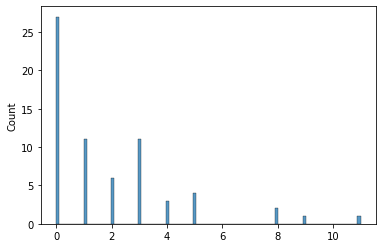

In [331]:
sns.histplot(my_data[3,25,:] , bins = 100)

In [325]:
try:
    p0 = estimate_pi0_naive(my_data[4,4,:])
except:
    p0 = 1
    

In [332]:
estimate_pi0_naive(my_data[3,25,:])

,pi_0,mu_FP,mu_TP,sigma_FP,sigma_TP
0,0.409091,2.51368,8.983626,1.31778,1.250382


In [321]:
my_map = np.ones(my_data.shape[:2])

In [322]:
for i in tqdm(range(my_data.shape[0])):
    for j in range(my_data.shape[0]):
        try:
            my_map[i,j] = estimate_pi0_naive(my_data[i,j,:]).pi_0.to_numpy()[0]
        except:
            continue

  0%|          | 0/95 [00:00<?, ?it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWa

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
  5%|▌         | 5/95 [00:01<00:25,  3.58it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: Conve

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1)

 21%|██        | 20/95 [00:05<00:22,  3.29it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 22%|██▏       | 21/95 [00:05<00:20,  3.63it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/s

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1)

...

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 67%|██████▋   | 64/95 [00:16<00:08,  3.67it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 68%|██████▊   | 65/95 [00:17<00:08,  3.53it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/s

 76%|███████▌  | 72/95 [00:19<00:06,  3.71it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 77%|███████▋  | 73/95 [00:19<00:05,  3.93it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/s

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 82%|████████▏ | 78/95 [00:20<00:04,  3.93it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: Conv

 92%|█████████▏| 87/95 [00:22<00:02,  3.81it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 93%|█████████▎| 88/95 [00:23<00:01,  3.74it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/s

/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
 98%|█████████▊| 93/95 [00:24<00:00,  4.63it/s]/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  label = cluster.KMeans(n_clusters=self.n_components, n_init=1,
/Users/lradosavljevic/opt/anaconda3/lib/python3.8/site-packages/sklearn/mixture/_base.py:147: Conv

In [196]:
my_map

array([[0.35846732, 0.62300189, 0.88726554, ..., 1.        , 1.        ,
        0.98484848],
       [0.62300189, 0.74559495, 0.83759918, ..., 1.        , 1.        ,
        0.54700619],
       [0.75465586, 0.83759918, 0.65908787, ..., 1.        , 1.        ,
        0.93939177],
       ...,
       [1.        , 1.        , 1.        , ..., 0.98484848, 0.98484848,
        0.80865124],
       [1.        , 1.        , 1.        , ..., 0.98484848, 0.92906481,
        0.98484848],
       [0.98484848, 0.54700619, 0.93939177, ..., 0.98484848, 0.98484848,
        0.46800528]])

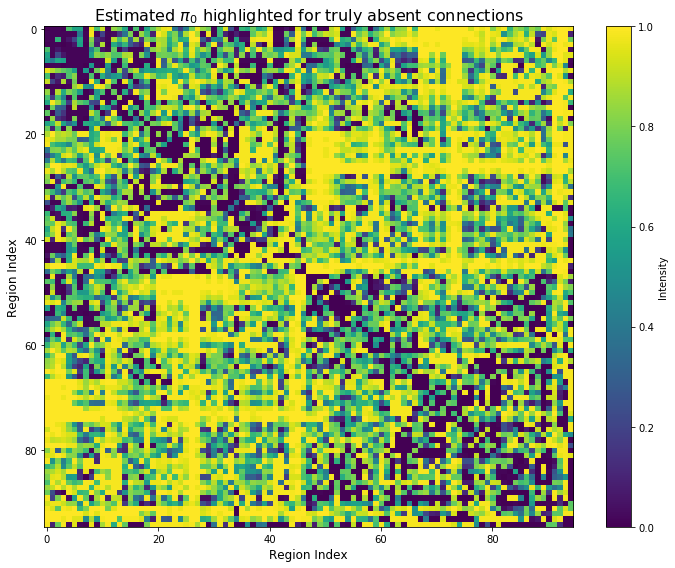

In [335]:
plt.figure(figsize=(10, 8))                  # Size in inches (width, height)
plt.imshow(my_map, cmap='viridis', aspect='auto')  # auto to avoid squishing
plt.colorbar(label='Intensity')
plt.title('Estimated $\pi_0$ highlighted for truly absent connections', fontsize=16)
plt.xlabel('Region Index', fontsize=12)
plt.ylabel('Region Index', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_structural_connectivity.png' , dpi = 400)
plt.show()